# Entrenamiento Detector PPE — YOLOv8 (cuaderno propio)

Este cuaderno es **independiente** del cuaderno del profesor. Entrena un detector de PPE (Equipo de Protección Personal) sobre el dataset **PPE Factory** de Roboflow con 7 clases: `boots, earmuffs, glasses, gloves, helmet, person, vest`.

**Pasos:**
1. Verificar GPU y preparar entorno.
2. Descargar dataset desde Roboflow.
3. Entrenar YOLOv8 con transfer learning.
4. Validar y probar.
5. Descargar `best.pt` para usarlo en la app Streamlit.

> Entorno recomendado: Google Colab con **GPU T4** (Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU).

## 1. Verificar GPU

In [1]:
import torch
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("ADVERTENCIA: No hay GPU. Cambia el entorno a GPU antes de continuar.")

CUDA disponible: True
GPU: Tesla T4
Memoria GPU: 15.6 GB


## 2. Instalar dependencias

In [2]:
!pip install ultralytics roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.8 MB/s eta 0:00:0000:01


In [3]:
import os
import shutil
from ultralytics import YOLO
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Descargar dataset desde Roboflow

Usamos el mismo dataset **PPE Factory** que vio el profesor en clase (7 clases).

> Si la API key deja de funcionar, crea una cuenta gratis en [roboflow.com](https://roboflow.com), entra al proyecto [ppe-factory-bmdcj](https://universe.roboflow.com/manuel-ybi42/ppe-factory-bmdcj-vb0jb) y copia tu propia API key.

In [4]:
!rm -rf /content/dataset /content/ppe-factory-1

from roboflow import Roboflow

rf = Roboflow(api_key="YOUR_ROBOFLOW_API_KEY")  # Crea tu propia key gratis en roboflow.com)
project = rf.workspace("cicatriz").project("ppe-factory-bmdcj-alnpk")
version = project.version(1)
dataset = version.download("yolov8")

print(f"Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-factory-1 in yolov8:: 100%|██████████| 21608/21608 [00:03<00:00, 6634.80it/s] 


Dataset descargado en: /content/ppe-factory-1


In [5]:
src = "/content/ppe-factory-1"
dst = "/content/dataset"

if os.path.exists(src):
    shutil.move(src, dst)
    print(f"Dataset movido a {dst}")
else:
    print(f"El dataset ya está en {dst}")

Dataset movido a /content/dataset


In [6]:
BASE_PATH = "/content/dataset"
subdirs = ["train/images", "train/labels", "valid/images", "valid/labels", "test/images", "test/labels"]

print("Estructura del dataset:")
for subdir in subdirs:
    full_path = os.path.join(BASE_PATH, subdir)
    n = len(os.listdir(full_path)) if os.path.exists(full_path) else 0
    print(f"  {subdir:<25} {n:>5} archivos")

print("\nContenido de data.yaml:")
with open(os.path.join(BASE_PATH, 'data.yaml'), 'r') as f:
    print(f.read())

Estructura del dataset:
  train/images               9770 archivos
  train/labels               9770 archivos
  valid/images                742 archivos
  valid/labels                742 archivos
  test/images                 286 archivos
  test/labels                 286 archivos

Contenido de data.yaml:
names:
- boots
- earmuffs
- glasses
- gloves
- helmet
- person
- vest
nc: 7
roboflow:
  license: CC BY 4.0
  project: ppe-factory-bmdcj-vb0jb
  url: https://universe.roboflow.com/manuel-ybi42/ppe-factory-bmdcj-vb0jb/dataset/1
  version: 1
  workspace: manuel-ybi42
test: ../test/images
train: ../train/images
val: ../valid/images



## 4. Montar Google Drive

Montamos Drive **antes** de entrenar para poder guardar el modelo automáticamente en cuanto termine. Así no se pierde si la sesión de Colab se cae después.

> Al ejecutar esta celda se abre una ventana/URL para autorizar el acceso a tu cuenta de Google.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/ppe_modelo"
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Drive montado. Se guardará en: {DRIVE_DIR}")

## 5. Entrenar el modelo

Cargamos `yolov8n.pt` (nano, el más rápido) con pesos preentrenados en COCO y hacemos **transfer learning** sobre PPE.

**Parámetros:**
- `epochs=50` — número de vueltas completas al dataset.
- `imgsz=640` — tamaño de imagen de entrada (640 da mejor precisión que 416).
- `batch=16` — imágenes por lote.

> Si vas con prisa o te queda poca GPU, baja a `epochs=25` o `imgsz=416`. El entrenamiento toma aproximadamente 30–60 min en una T4.

Al terminar, la celda copia automáticamente `best.pt` a tu Drive.

In [7]:
model = YOLO("yolov8n.pt")
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
import shutil

results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="ppe_detector",
    project="/content/runs",
)
print("Entrenamiento finalizado.")

# Guardar inmediatamente en Drive para no perder el modelo
weights_dir = "/content/runs/ppe_detector/weights"
shutil.copy2(f"{weights_dir}/best.pt", f"{DRIVE_DIR}/best.pt")
shutil.copy2(f"{weights_dir}/last.pt", f"{DRIVE_DIR}/last.pt")
print(f"Modelo copiado a {DRIVE_DIR}/best.pt")

## 6. Evaluar el modelo

In [9]:
best_path = "/content/runs/ppe_detector/weights/best.pt"
model = YOLO(best_path)
metrics = model.val(data="/content/dataset/data.yaml")

print("\nMétricas globales:")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  Precisión: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1488.3±544.2 MB/s, size: 41.4 KB)
val: Scanning /content/dataset/valid/labels.cache... 742 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 742/742 163.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 4.8it/s 9.7s0.1s
                   all        742       3828      0.762      0.708      0.764      0.506
                 boots        288        652       0.92      0.782      0.883      0.596
              earmuffs        218        344      0.663      0.571      0.651       0.39
               glasses        222        264       0.71      0.631      0.723      0.383
                gloves        150        310      0.379      0.452      0.402      0.235
                helmet        482        802

results.png


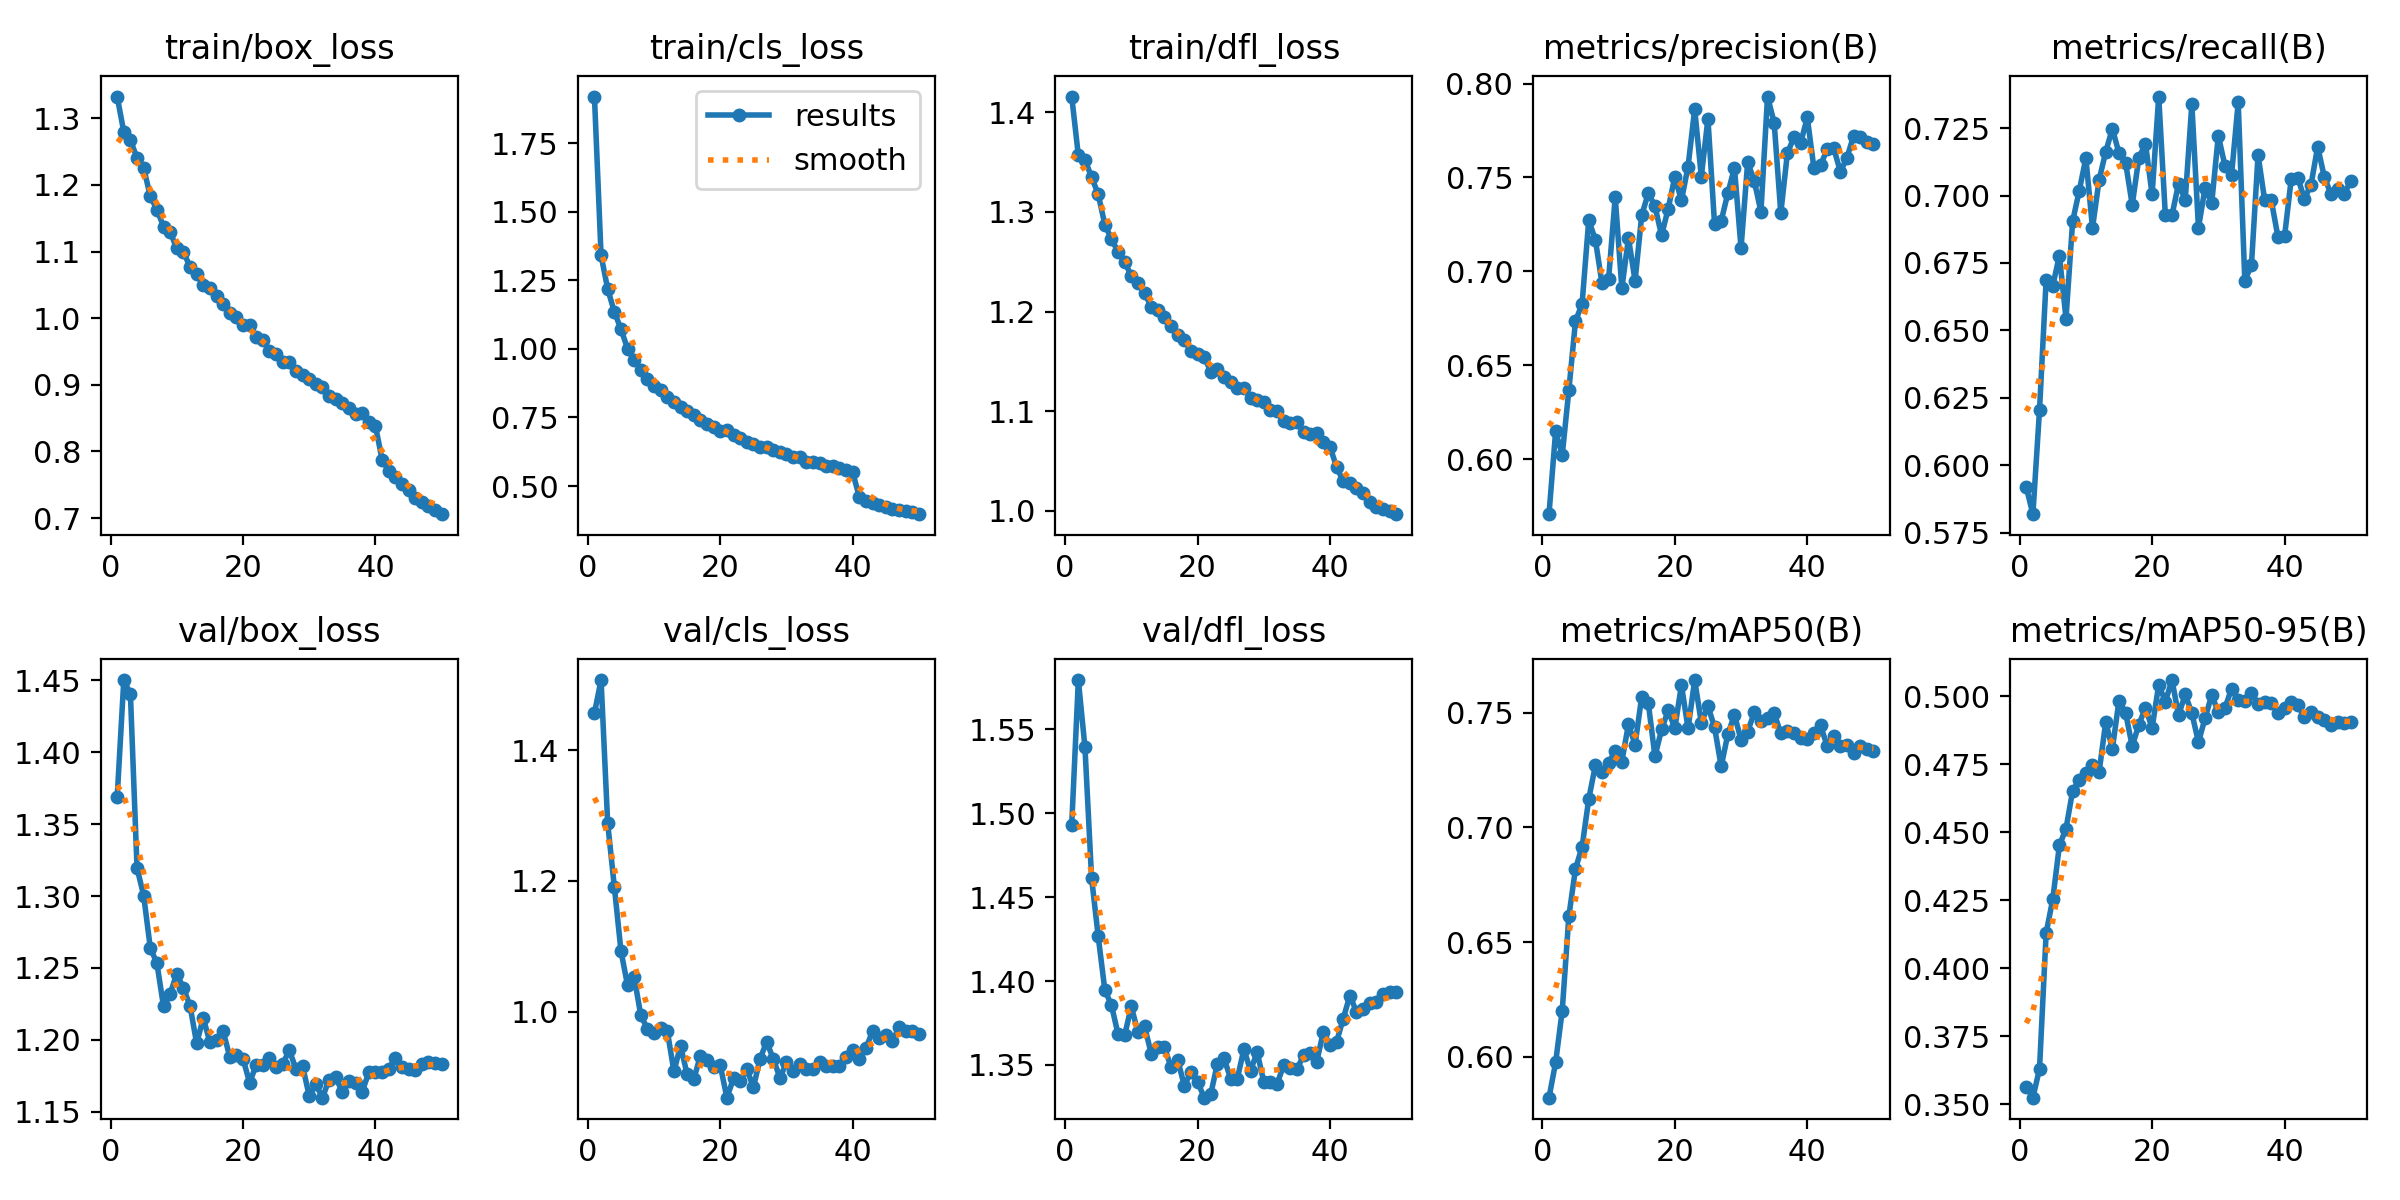

confusion_matrix.png


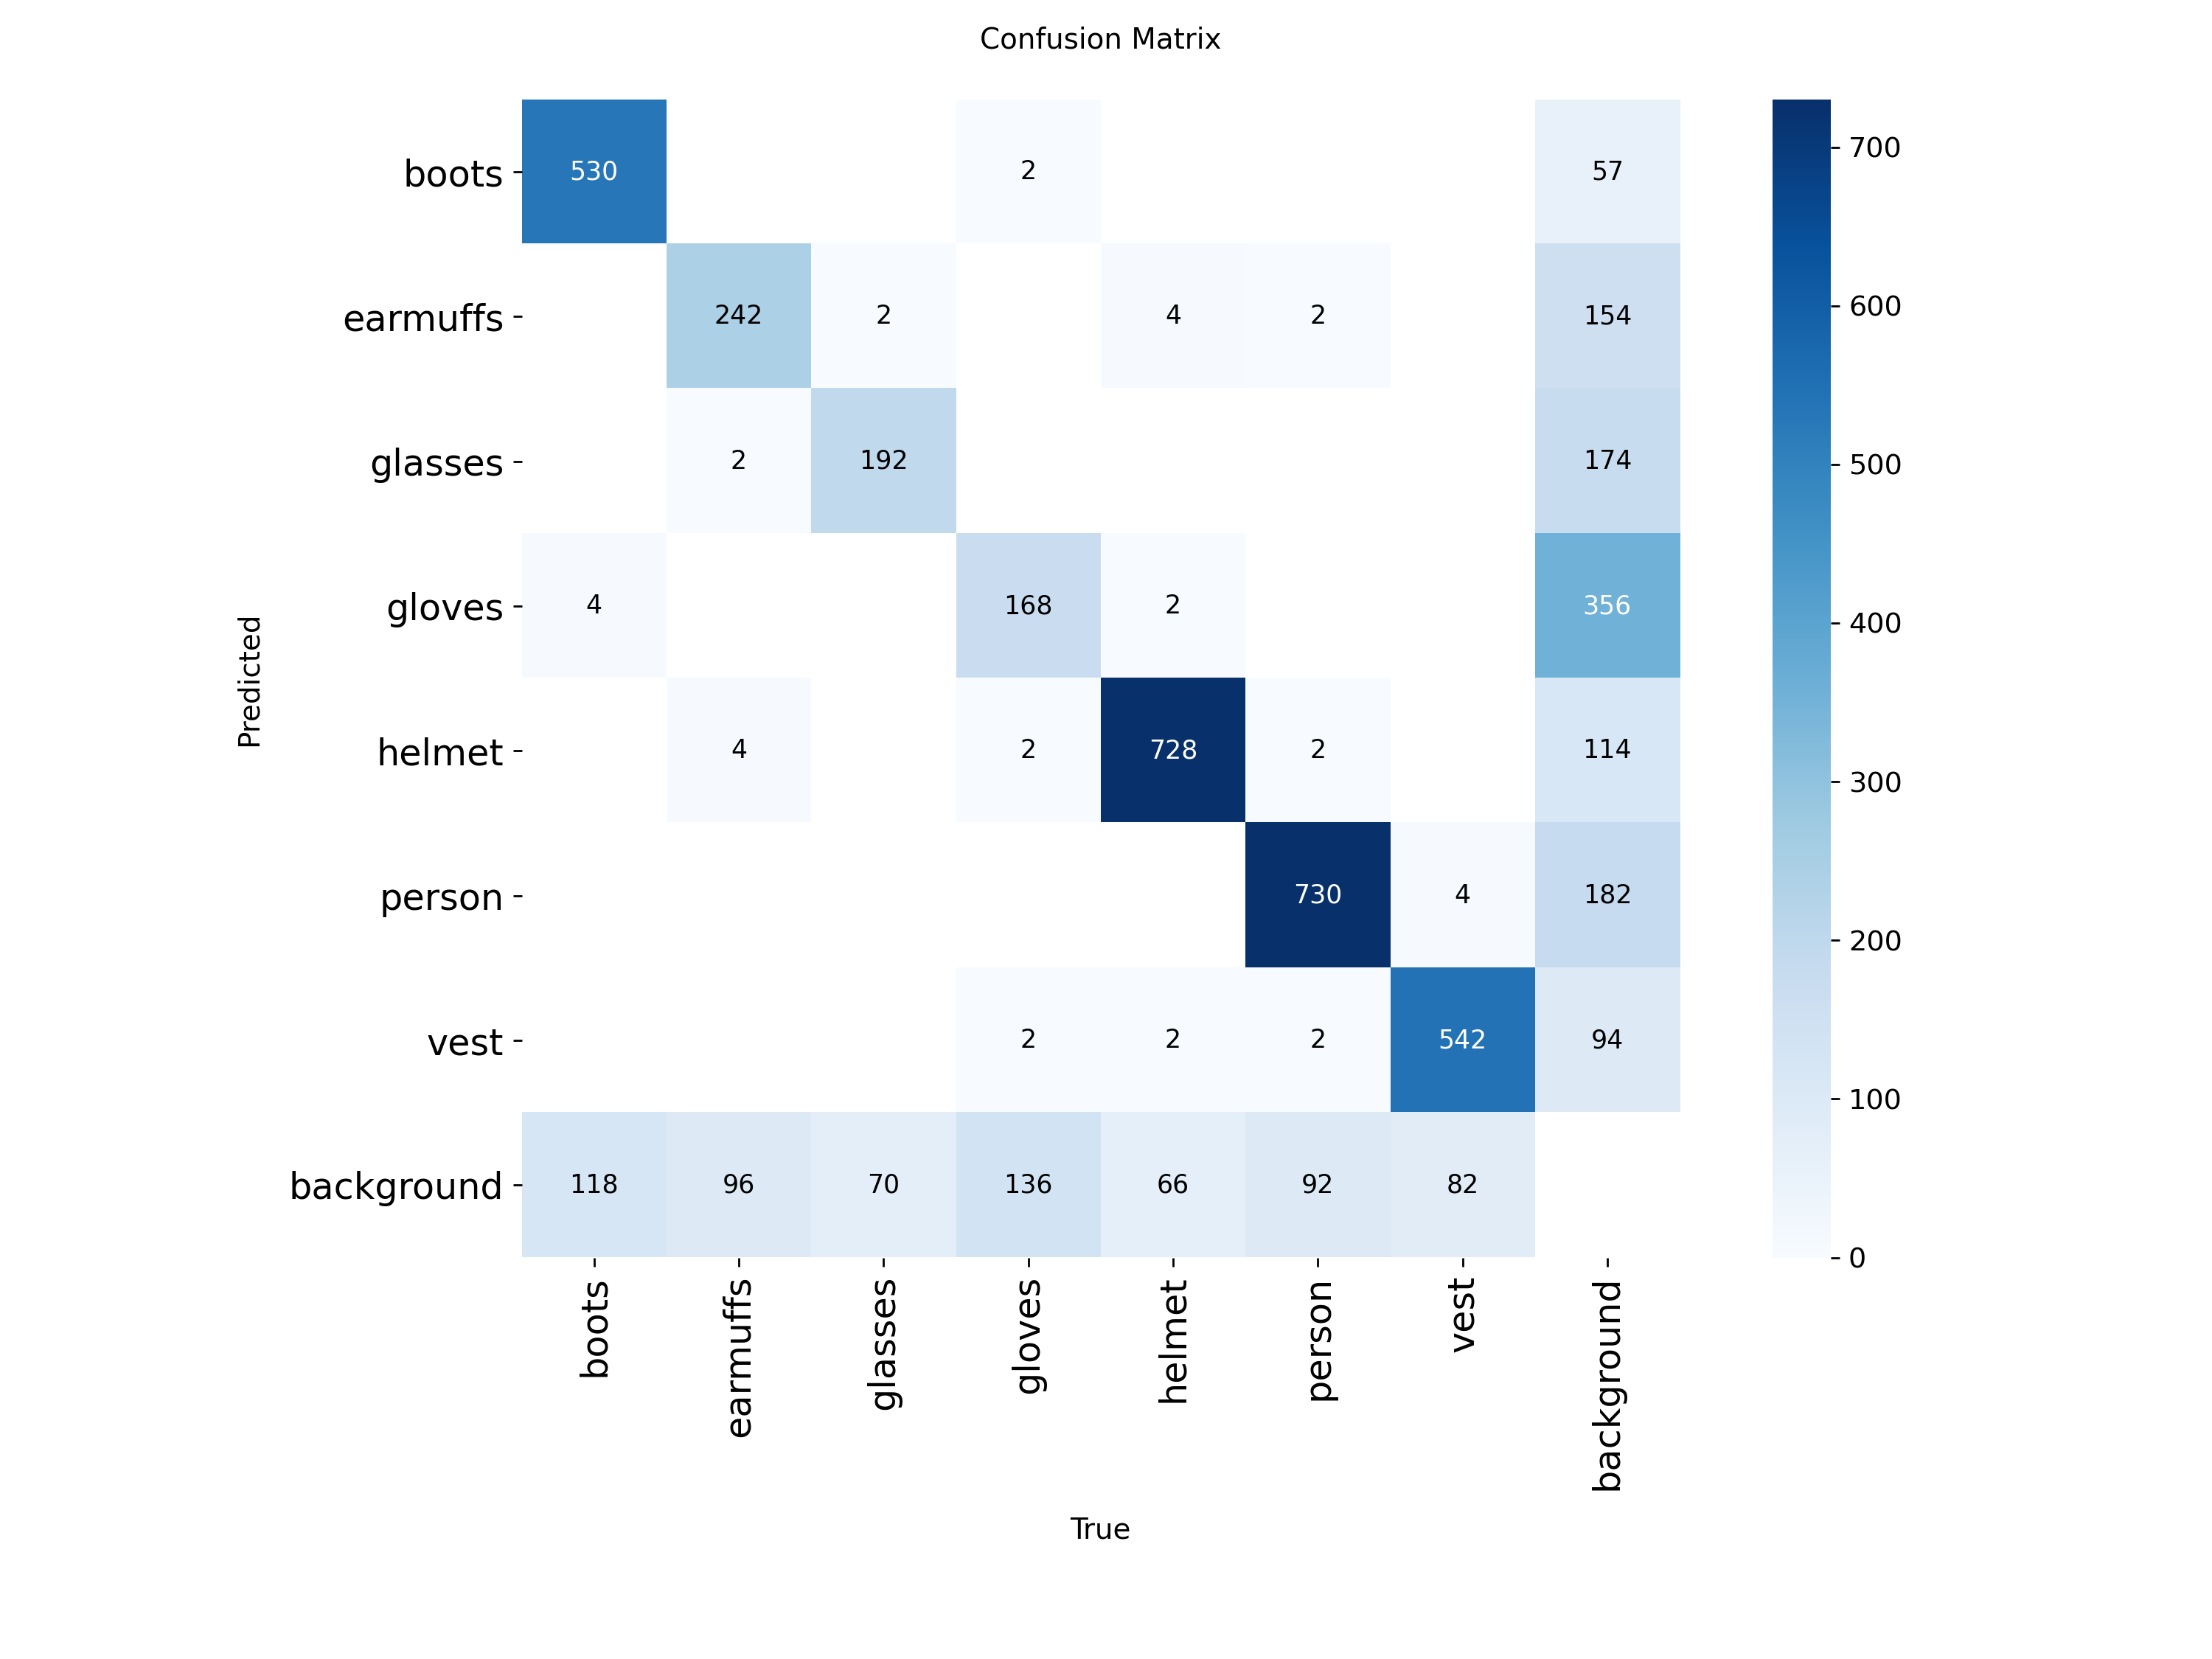

In [10]:
for plot_name in ["results.png", "confusion_matrix.png", "F1_curve.png", "PR_curve.png"]:
    plot_path = f"/content/runs/ppe_detector/{plot_name}"
    if os.path.exists(plot_path):
        print(plot_name)
        display(Image(filename=plot_path, width=700))

Results saved to /content/runs/detect/predict
IMG_6499-e1439982204742_jpg.rf.d59ee3349cea053af9f9dab1730b4319.jpg: 28 detecciones


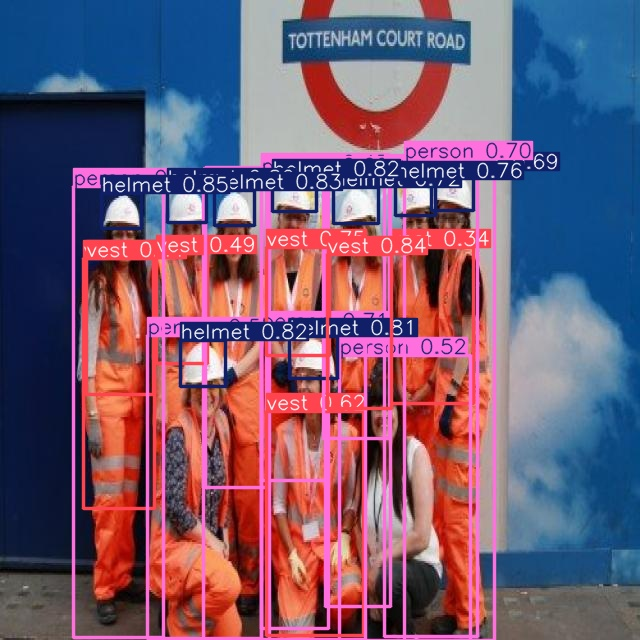

Results saved to /content/runs/detect/predict
images11_jpg.rf.70106d89164a5c1e6dfeeb69b6877cca.jpg: 3 detecciones


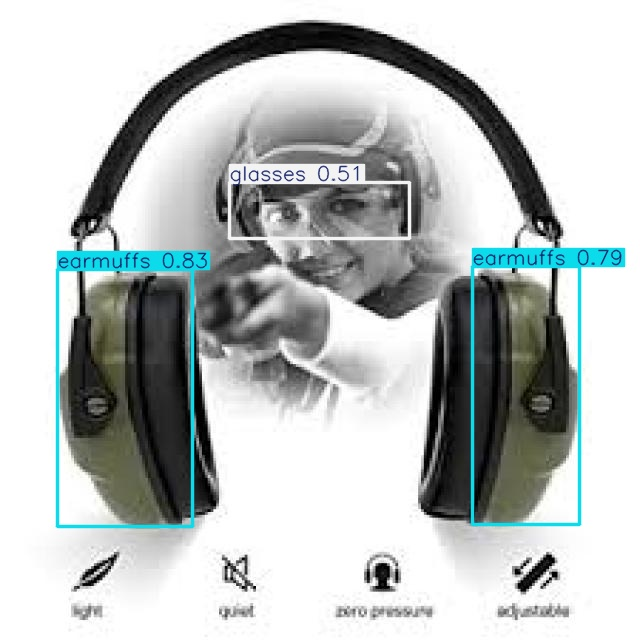

Results saved to /content/runs/detect/predict
Video4_273_jpg.rf.34a44a8eaa162511f9174c8e693d4457.jpg: 7 detecciones


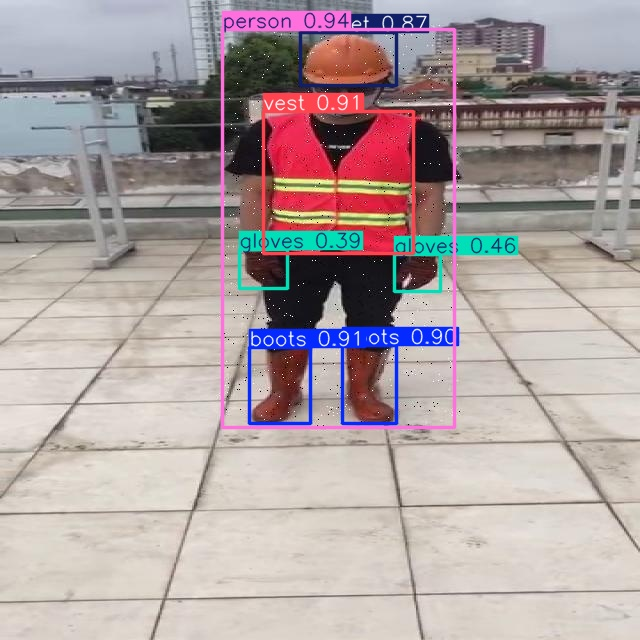

In [11]:
test_dir = "/content/dataset/test/images"
test_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

for filename in test_images[:3]:
    image_path = os.path.join(test_dir, filename)
    results = model.predict(image_path, save=True, imgsz=640, conf=0.25, verbose=False)
    print(f"{filename}: {len(results[0].boxes)} detecciones")
    display(Image(filename=os.path.join(results[0].save_dir, filename), width=500))

## 6. Copiar gráficas y verificar

Copiamos también las gráficas de entrenamiento a Drive y listamos lo que quedó guardado.

In [ ]:
import shutil, os

run_dir = "/content/runs/ppe_detector"
for f in ["results.png", "confusion_matrix.png", "F1_curve.png", "PR_curve.png", "results.csv"]:
    src = os.path.join(run_dir, f)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(DRIVE_DIR, f))

print(f"Contenido de {DRIVE_DIR}:")
for f in sorted(os.listdir(DRIVE_DIR)):
    size_mb = os.path.getsize(os.path.join(DRIVE_DIR, f)) / 1e6
    print(f"  {f:<30} {size_mb:>6.2f} MB")

---

**Siguientes pasos en local:**
1. Entra a [drive.google.com](https://drive.google.com) en tu Mac.
2. Abre la carpeta **`ppe_modelo`** y descarga `best.pt`.
3. Cópialo a la carpeta del proyecto (misma carpeta que `app.py`).
4. En terminal: `pip install -r requirements.txt && streamlit run app.py`